# **Social Media Engagement Analytics**

Task 1 — Data Import & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("social_media_engagement_5000.csv")
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)


Shape: (5000, 19)

Columns:
Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='str')


In [4]:
print("\nData Types:")
print(df.dtypes)


Data Types:
user_id               int64
age                 float64
gender                  str
country                 str
post_id               int64
post_type               str
post_category           str
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at               str
follower_count        int64
is_verified            bool
device_type             str
sentiment               str
hashtags                str
engagement_rate     float64
dtype: object


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   str    
 3   country           5000 non-null   str    
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   str    
 6   post_category     5000 non-null   str    
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   str    
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   str    
 16  sentiment         4850 non-null   str    
 17  hashta

In [6]:
df['posted_at'] = pd.to_datetime(df['posted_at'], format='%d-%m-%Y')

df['posted_at'].head()

0   2022-12-17
1   2023-06-02
2   2023-05-07
3   2023-02-12
4   2023-05-23
Name: posted_at, dtype: datetime64[us]

In [7]:
likes_array = np.array(df['likes'].dropna())

print("Maximum likes:", np.max(likes_array))
print("Minimum likes:", np.min(likes_array))
print("Average likes:", np.mean(likes_array))

Maximum likes: 19998.0
Minimum likes: 10.0
Average likes: 10107.043711340206


Task 2 — Data Cleaning

In [8]:
## Cleaning missing data

print("Missing values:")
print(df.isnull().sum())


Missing values:
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [9]:
#filling missing numerical values
df['age'] = df['age'].fillna(df['age'].median())

df['likes'] = df['likes'].fillna(df['likes'].median())

df['comments'] = df['comments'].fillna(df['comments'].median())

df['shares'] = df['shares'].fillna(df['shares'].median())

In [10]:
#filling missing categorical values
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])

In [11]:
#checking whether missing values remains
print(df.isnull().sum())

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


In [12]:
print(df.isna().sum())

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


In [13]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [14]:
#converting the datatype

df['age'] = df['age'].round().astype('int64')
df['likes'] = df['likes'].round().astype('int64')
df['comments'] = df['comments'].round().astype('int64')
df['shares'] = df['shares'].round().astype('int64')

#rounding is used because these columns represent whole-number values,not fractions.

In [15]:
#checking the datatype of each column
print(df[['age','likes','comments','shares']].dtypes)

age         int64
likes       int64
comments    int64
shares      int64
dtype: object


In [16]:
# standardising categorical values

df['gender'] = df['gender'].str.strip().str.lower()
df['post_type'] = df['post_type'].str.strip().str.lower()
df['post_category'] = df['post_category'].str.strip().str.lower()
df['sentiment'] = df['sentiment'].str.strip().str.lower()
df['device_type'] = df['device_type'].str.strip().str.lower()
df['country'] = df['country'].str.strip()

#.str.strip() removes unnecessary spaces.
#.str.lower() converts text to lowercase.
#Country names are stripped of extra spaces while keeping their original capitalisation.

In [17]:
#checking cleaned categories

print("Gender:", df['gender'].unique())
print("Post types:", df['post_type'].unique())
print("Post categories:", df['post_category'].unique())
print("Sentiments:", df['sentiment'].unique())
print("Device types:", df['device_type'].unique())

Gender: <StringArray>
['female', 'male', 'other']
Length: 3, dtype: str
Post types: <StringArray>
['image', 'reel', 'text', 'video']
Length: 4, dtype: str
Post categories: <StringArray>
[  'fitness',      'food',      'tech',    'travel',   'fashion', 'lifestyle',
 'education',     'music']
Length: 8, dtype: str
Sentiments: <StringArray>
['negative', 'positive', 'neutral']
Length: 3, dtype: str
Device types: <StringArray>
['mobile', 'tablet', 'desktop']
Length: 3, dtype: str


In [18]:
#checking unrealistic values
print(df[['likes', 'comments', 'shares']].describe())

              likes     comments     shares
count   5000.000000  5000.000000  5000.0000
mean   10107.012400  1502.039800  1002.9106
std     5702.293014   856.393312   570.8552
min       10.000000     0.000000     0.0000
25%     5235.000000   792.000000   511.0000
50%    10106.000000  1497.000000  1012.0000
75%    14959.000000  2235.250000  1483.0000
max    19998.000000  2999.000000  1999.0000


In [19]:

print("Negative likes:", (df['likes'] < 0).sum())
print("Negative comments:", (df['comments'] < 0).sum())
print("Negative shares:", (df['shares'] < 0).sum())

Negative likes: 0
Negative comments: 0
Negative shares: 0


**Result:** No negative values were found in the likes, comments, or shares columns. The values were checked using summary statistics, and no corrections were required.

In [20]:
#checking how hashtags are stored in the dataset
print(df['hashtags'].head(10))

0      #foodie #travel #love
1                   #fitness
2                    #foodie
3        #music #foodie #fun
4                    #travel
5                   #fitness
6                     #music
7    #travel #music #fitness
8       #music #fun #fitness
9           #lifestyle #love
Name: hashtags, dtype: str


In [21]:
# Counting the number of hashtags in each post
df['hashtag_count'] = df['hashtags'].str.count('#')

# Checking the result
print(df[['hashtags', 'hashtag_count']].head(10))

                  hashtags  hashtag_count
0    #foodie #travel #love              3
1                 #fitness              1
2                  #foodie              1
3      #music #foodie #fun              3
4                  #travel              1
5                 #fitness              1
6                   #music              1
7  #travel #music #fitness              3
8     #music #fun #fitness              3
9         #lifestyle #love              2


In [22]:
# Cleaning sentiment labels
df['sentiment'] = df['sentiment'].str.strip().str.lower()

# Checking the cleaned sentiment labels
print(df['sentiment'].unique())

# Checking the number of posts in each sentiment
print(df['sentiment'].value_counts())

<StringArray>
['negative', 'positive', 'neutral']
Length: 3, dtype: str
sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64


Task 3 — Data Exploration using Pandas

In [23]:
# Displaying the first five rows
print(df.head())


   user_id  age  gender country  post_id post_type post_category  likes  \
0    25795   43  female  Brazil   496713     image       fitness   7011   
1    10860   33    male  Brazil   157326      reel          food  11750   
2    86820   32  female      UK   109864      text          food   4862   
3    64886   51   other  France   848877      text       fitness   5350   
4    16265   34   other      UK   449706     image       fitness  12682   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0       354    1157            5726             44650 2022-12-17   
1      2606    1807            5947             80216 2023-06-02   
2       344     955            6946             44858 2023-05-07   
3      1083    1049             229             70455 2023-02-12   
4      2735    1300            4798              6019 2023-05-23   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      mobile  negative  #foodie

In [24]:
# Displaying the last five rows
print(df.tail())

      user_id  age  gender    country  post_id post_type post_category  likes  \
4995    59500   44    male  Australia   441541     video     education  16210   
4996    22100   38   other        UAE   677076      reel     education  16924   
4997    67021   63  female        USA   273595      text        travel  13487   
4998    29800   13  female    Germany   785644     video       fitness  16894   
4999    73400   54   other      Japan   712252      text        travel  14830   

      comments  shares  watch_time_sec  impression_count  posted_at  \
4995      2013    1837            6190             42977 2022-06-25   
4996      2734    1583            7764             34196 2022-11-18   
4997      1497     167            7466             23680 2023-04-06   
4998      1289    1713            4991             89013 2022-05-16   
4999       503    1798            3743             14234 2023-03-04   

      follower_count  is_verified device_type sentiment  \
4995          646147       

In [25]:
# Checking the number of rows and columns
print("Dataset shape:", df.shape)

Dataset shape: (5000, 20)


In [26]:
# Displaying all column names
print("Column names:")
print(df.columns)

Column names:
Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='str')


In [27]:
# Checking data types
print(df.dtypes)

user_id                      int64
age                          int64
gender                         str
country                        str
post_id                      int64
post_type                      str
post_category                  str
likes                        int64
comments                     int64
shares                       int64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[us]
follower_count               int64
is_verified                   bool
device_type                    str
sentiment                      str
hashtags                       str
engagement_rate            float64
hashtag_count                int64
dtype: object


In [28]:
# Summary statistics for numerical columns
print(df.describe())

            user_id          age        post_id         likes     comments  \
count   5000.000000  5000.000000    5000.000000   5000.000000  5000.000000   
mean   54561.890800    38.440400  548042.909000  10107.012400  1502.039800   
min    10055.000000    13.000000  100068.000000     10.000000     0.000000   
25%    32309.500000    26.000000  322543.500000   5235.000000   792.000000   
50%    54374.500000    38.000000  548077.500000  10106.000000  1497.000000   
75%    77180.500000    51.000000  771574.500000  14959.000000  2235.250000   
max    99963.000000    64.000000  999455.000000  19998.000000  2999.000000   
std    26090.370121    14.687151  260646.957267   5702.293014   856.393312   

          shares  watch_time_sec  impression_count  \
count  5000.0000     5000.000000       5000.000000   
mean   1002.9106     4014.503200      50013.732800   
min       0.0000        0.000000        105.000000   
25%     511.0000     2017.750000      24988.250000   
50%    1012.0000     4034.5

In [29]:
# Check the dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   str           
 3   country           5000 non-null   str           
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   str           
 6   post_category     5000 non-null   str           
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[us]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 non-null   b

In [30]:
# Check the number of posts for each gender
print(df['gender'].value_counts())

# Check the number of posts for each post type
print(df['post_type'].value_counts())

gender
male      1849
other     1581
female    1570
Name: count, dtype: int64
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64


In [31]:
# Check the number of posts for each category
print(df['post_category'].value_counts())

# Check the number of posts for each sentiment
print(df['sentiment'].value_counts())

# Check the number of posts for each device
print(df['device_type'].value_counts())

post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594
food         593
Name: count, dtype: int64
sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64
device_type
mobile     1684
tablet     1658
desktop    1658
Name: count, dtype: int64


In [32]:
# Count the unique values in selected columns
print("Unique genders:", df['gender'].nunique())
print("Unique post types:", df['post_type'].nunique())
print("Unique categories:", df['post_category'].nunique())
print("Unique sentiments:", df['sentiment'].nunique())
print("Unique devices:", df['device_type'].nunique())

Unique genders: 3
Unique post types: 4
Unique categories: 8
Unique sentiments: 3
Unique devices: 3


In [33]:
# Select numerical columns for correlation
numeric_columns = [
    'age',
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'impression_count',
    'follower_count',
    'engagement_rate',
    'hashtag_count'
]

# Create the correlation matrix
correlation_matrix = df[numeric_columns].corr()

In [34]:
# Display the result
print(correlation_matrix)

                       age     likes  comments    shares  watch_time_sec  \
age               1.000000 -0.036322 -0.007284  0.013871        0.005542   
likes            -0.036322  1.000000 -0.018421  0.004712        0.008711   
comments         -0.007284 -0.018421  1.000000  0.006142       -0.016351   
shares            0.013871  0.004712  0.006142  1.000000        0.014658   
watch_time_sec    0.005542  0.008711 -0.016351  0.014658        1.000000   
impression_count  0.013322  0.007952 -0.009395 -0.005204       -0.004335   
follower_count   -0.024894 -0.022982 -0.011733 -0.010783        0.002761   
engagement_rate   0.008039  0.093520  0.000051  0.021724       -0.001148   
hashtag_count     0.007173 -0.002189 -0.015230  0.013379       -0.023301   

                  impression_count  follower_count  engagement_rate  \
age                       0.013322       -0.024894         0.008039   
likes                     0.007952       -0.022982         0.093520   
comments                 -

In [35]:
# Find the average likes for each post type
avg_likes = df.groupby('post_type')['likes'].mean()

print(avg_likes)

post_type
image    10104.878107
reel     10037.819953
text     10100.163855
video    10188.613878
Name: likes, dtype: float64


In [36]:
# Find the average impressions for each country
avg_impressions = df.groupby('country')['impression_count'].mean()

print(avg_impressions.sort_values(ascending=False))

country
India        52462.386916
France       51727.673387
USA          51263.872255
UK           51119.393509
Japan        49616.135593
Brazil       49193.174603
UAE          48928.413519
Canada       48703.150097
Germany      48605.406122
Australia    48346.383367
Name: impression_count, dtype: float64


In [37]:
# Find the average engagement rate for each category
avg_engagement = df.groupby('post_category')['engagement_rate'].mean()

print(avg_engagement.sort_values(ascending=False))

post_category
food         1.358628
tech         1.160475
lifestyle    1.091019
music        0.888803
fitness      0.865628
education    0.844222
fashion      0.807109
travel       0.702223
Name: engagement_rate, dtype: float64


In [38]:
# Checking the number of posts in each category
print(df['post_type'].value_counts())
print(df['post_category'].value_counts())
print(df['country'].value_counts())
print(df['device_type'].value_counts())
print(df['is_verified'].value_counts())

post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64
post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594
food         593
Name: count, dtype: int64
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64
device_type
mobile     1684
tablet     1658
desktop    1658
Name: count, dtype: int64
is_verified
False    4517
True      483
Name: count, dtype: int64


In [39]:
# Creating an engagement score for each post
df['engagement_score'] = df['likes'] + df['comments'] + df['shares']

# Checking the result
print(df[['likes', 'comments', 'shares', 'engagement_score']].head())

#It adds likes, comments and shares together to calculate a simple engagement score for each post.

   likes  comments  shares  engagement_score
0   7011       354    1157              8522
1  11750      2606    1807             16163
2   4862       344     955              6161
3   5350      1083    1049              7482
4  12682      2735    1300             16717


In [40]:
# Comparing engagement across different post types
post_type_analysis = df.groupby('post_type').agg(
    average_likes=('likes', 'mean'),
    average_comments=('comments', 'mean'),
    average_shares=('shares', 'mean'),
    average_engagement=('engagement_score', 'mean')
)

print(post_type_analysis)

# this compare image, reel, text and video posts using their average engagement metrics.

           average_likes  average_comments  average_shares  average_engagement
post_type                                                                     
image       10104.878107       1525.235766     1019.289495        12649.403368
reel        10037.819953       1504.187062      982.042089        12524.049104
text        10100.163855       1499.106024     1013.989558        12613.259438
video       10188.613878       1479.160000      996.834286        12664.608163


In [41]:
# Comparing engagement for each sentiment
sentiment_analysis = df.groupby('sentiment').agg(
    average_likes=('likes', 'mean'),
    average_comments=('comments', 'mean'),
    average_shares=('shares', 'mean'),
    average_engagement=('engagement_score', 'mean')
)

print(sentiment_analysis)

#This compares positive, neutral and negative posts using their average likes, comments, shares and total engagement.

           average_likes  average_comments  average_shares  average_engagement
sentiment                                                                     
negative    10208.112500       1516.094792     1007.307292        12731.514583
neutral      9923.208906       1528.404060      996.565160        12448.178127
positive    10180.077199       1480.650617     1005.086749        12665.814564


In [42]:
# Comparing engagement across countries
country_analysis = df.groupby('country').agg(
    average_likes=('likes', 'mean'),
    average_comments=('comments', 'mean'),
    average_shares=('shares', 'mean'),
    average_engagement=('engagement_score', 'mean')
)

print(country_analysis.sort_values(
    by='average_engagement',
    ascending=False
))

#It calculates the average likes, comments, shares and total engagement for each country,
#  then displays the countries in descending order of average engagement.

           average_likes  average_comments  average_shares  average_engagement
country                                                                       
France      10372.889113       1478.695565     1051.812500        12903.397177
Australia   10294.141988       1485.803245     1029.693712        12809.638945
UAE         10227.500994       1541.214712      989.075547        12757.791252
Germany     10130.481633       1531.826531      973.379592        12635.687755
Canada      10063.077973       1546.582846      996.245614        12605.906433
Japan       10088.872881       1530.434322      959.351695        12578.658898
USA         10122.373253       1457.958084      995.141717        12575.473054
India        9962.491589       1494.917757     1035.315888        12492.725234
Brazil       9886.700397       1490.434524     1008.859127        12385.994048
UK           9935.663286       1463.042596      985.681542        12384.387424


Task-4 Data Wrangling

In [43]:
# Check the new columns created in the dataset
print(df[['likes', 'comments', 'shares', 'engagement_score', 'hashtag_count']].head())

   likes  comments  shares  engagement_score  hashtag_count
0   7011       354    1157              8522              3
1  11750      2606    1807             16163              1
2   4862       344     955              6161              1
3   5350      1083    1049              7482              3
4  12682      2735    1300             16717              1


In [44]:
# Create a log-transformed column for likes
df['log_likes'] = np.log1p(df['likes'])

# Display the original likes and log_likes
print(df[['likes', 'log_likes']].head())

#The log_likes column reduces the effect of very large like counts and can be useful for analysis. We use np.log1p() 
#because it calculates the natural logarithm of 1+likes, including when likes are zero.

   likes  log_likes
0   7011   8.855378
1  11750   9.371694
2   4862   8.489411
3   5350   8.585039
4  12682   9.448018


#Merge, join or concatenate — not necessary because we're working with a single DataFrame.

Task-5 Statistical Analysis

In [45]:
# Statistical analysis of numerical columns

columns = ['likes', 'comments', 'shares',
           'watch_time_sec', 'engagement_rate',
           'follower_count']

# Calculate mean, median, mode, standard deviation and variance
for column in columns:
    print("\nStatistics for", column)

    print("Mean:", df[column].mean())
    print("Median:", df[column].median())
    print("Mode:", df[column].mode()[0])
    print("Standard Deviation:", df[column].std())
    print("Variance:", df[column].var())

    # Calculate percentiles
    print("25th Percentile:", df[column].quantile(0.25))
    print("50th Percentile:", df[column].quantile(0.50))
    print("75th Percentile:", df[column].quantile(0.75))

#Mean: Calculates the average value.
#Median: Finds the middle value.
#Mode: Finds the most frequently occurring value.
#Standard deviation: Measures how spread out the values are.
#Variance: Measures the spread of values using squared deviations.
#Percentiles: Show the values below which 25%, 50%, and 75% of the observations fall.


Statistics for likes
Mean: 10107.0124
Median: 10106.0
Mode: 10106
Standard Deviation: 5702.293013882177
Variance: 32516145.616169475
25th Percentile: 5235.0
50th Percentile: 10106.0
75th Percentile: 14959.0

Statistics for comments
Mean: 1502.0398
Median: 1497.0
Mode: 1497
Standard Deviation: 856.3933120458984
Variance: 733409.5049169434
25th Percentile: 792.0
50th Percentile: 1497.0
75th Percentile: 2235.25

Statistics for shares
Mean: 1002.9106
Median: 1012.0
Mode: 1012
Standard Deviation: 570.8551999758852
Variance: 325875.65933950787
25th Percentile: 511.0
50th Percentile: 1012.0
75th Percentile: 1483.0

Statistics for watch_time_sec
Mean: 4014.5032
Median: 4034.5
Mode: 916
Standard Deviation: 2308.0964590420845
Variance: 5327309.264242608
25th Percentile: 2017.75
50th Percentile: 4034.5
75th Percentile: 6020.25

Statistics for engagement_rate
Mean: 0.9643560291583999
Median: 0.2538959065
Mode: 0.006362909
Standard Deviation: 5.31802922266154
Variance: 28.281434813082104
25th Perc

Task-6 Data Visualization

Part A — Matplotlib visualizations

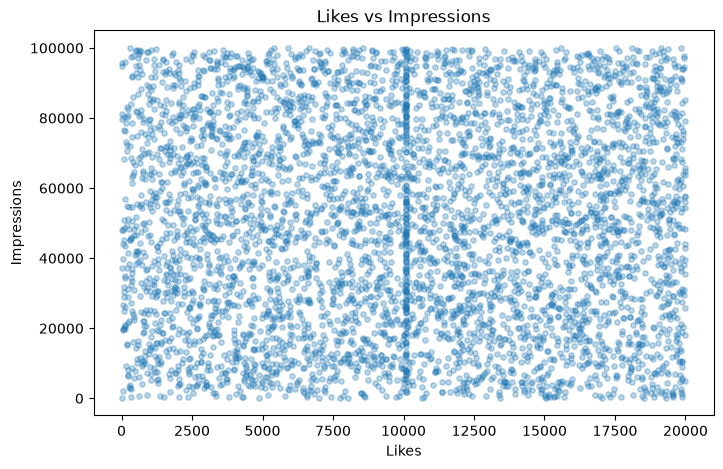

In [46]:
# Scatter plot: Likes vs Impressions
# Scatter plot to compare likes and impressions

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df['likes'], df['impression_count'],alpha = 0.3,s=15)

plt.title('Likes vs Impressions')
plt.xlabel('Likes')
plt.ylabel('Impressions')

plt.show()

#Each dot represents a post. It helps us see whether posts with more impressions tend to receive more likes.

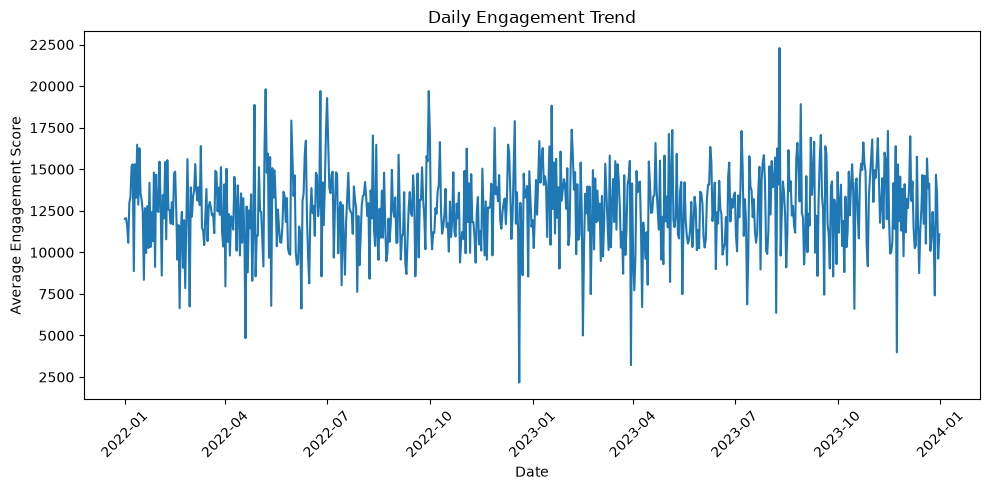

In [47]:
# Line plot: Daily Engagement Trend
# Calculate average engagement for each day

daily_engagement = df.groupby('posted_at')['engagement_score'].mean().reset_index()

# Plot the daily engagement trend
plt.figure(figsize=(10, 5))
plt.plot(daily_engagement['posted_at'], daily_engagement['engagement_score'])

plt.title('Daily Engagement Trend')
plt.xlabel('Date')
plt.ylabel('Average Engagement Score')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#It shows how the average engagement score changes from day to day.

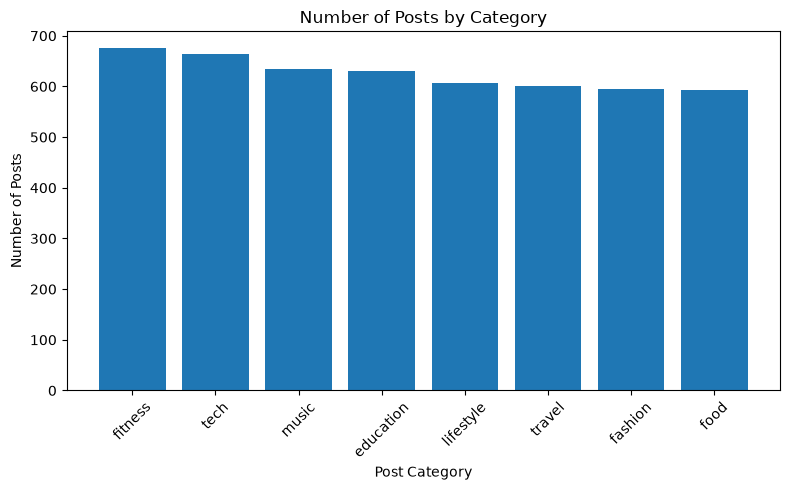

In [48]:
# Bar chart: Number of Posts by Category
# Count the number of posts in each category

post_counts = df['post_category'].value_counts()

# Create a bar chart
plt.figure(figsize=(8, 5))
plt.bar(post_counts.index, post_counts.values)

plt.title('Number of Posts by Category')
plt.xlabel('Post Category')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

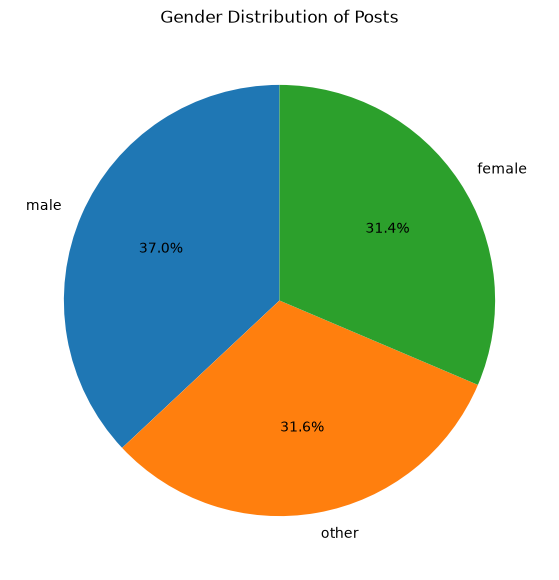

In [72]:
# Pie chart: Gender Distribution
# Count users by gender

gender_counts = df['gender'].value_counts()

# Draw the pie chart

plt.figure(figsize=(7, 7))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Gender Distribution of Posts')
plt.show()

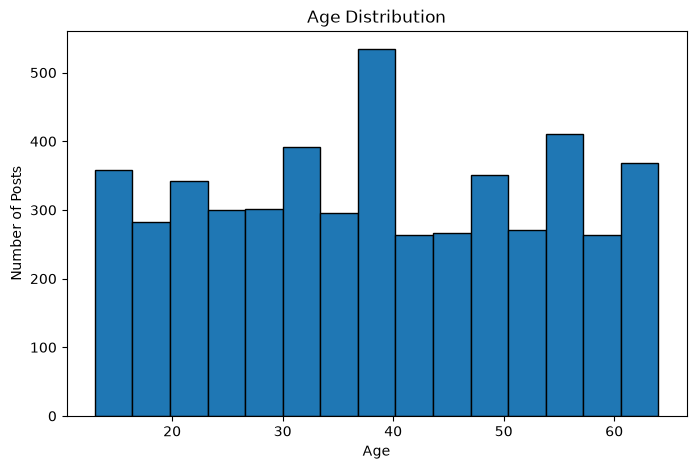

In [73]:
#Histogram: Age Distribution
#  Display the distribution of user ages

plt.figure(figsize=(8, 5))

plt.hist(df['age'].dropna(), bins=15, edgecolor='black')

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Posts')

plt.show()

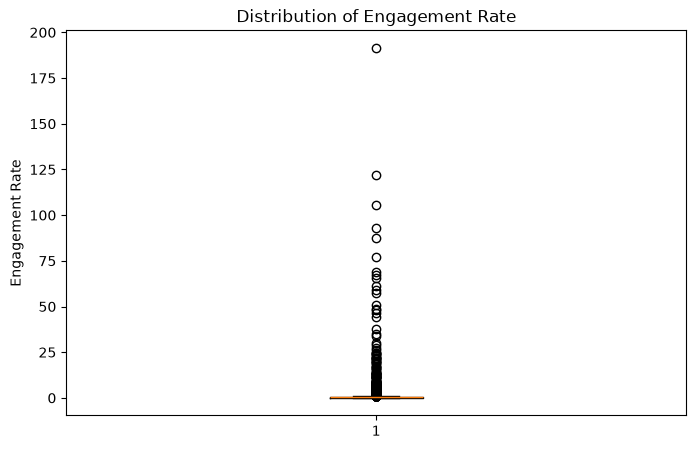

In [51]:
#Box plot: Engagement Rate
# Examine the distribution of engagement rates

plt.figure(figsize=(8, 5))

plt.boxplot(df['engagement_rate'].dropna())

plt.title('Distribution of Engagement Rate')
plt.ylabel('Engagement Rate')

plt.show()

Part B — Seaborn visualizations

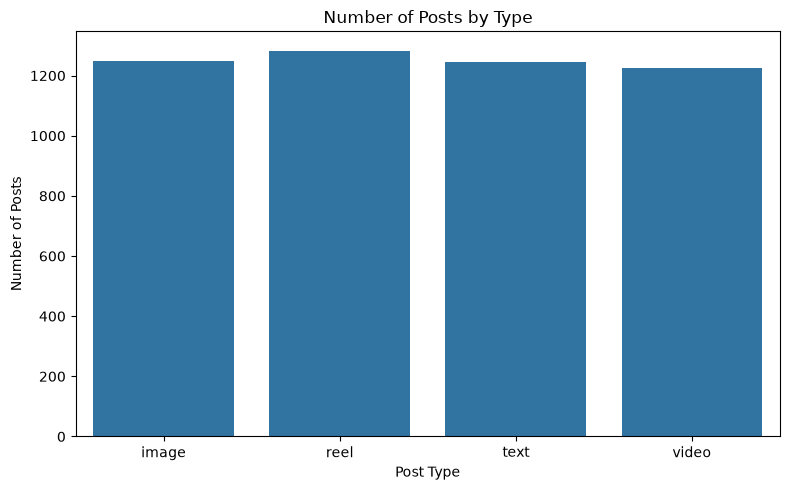

In [52]:
#Count plot: Posts by Post Type
# Compare the number of posts by type

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='post_type')

plt.title('Number of Posts by Type')
plt.xlabel('Post Type')
plt.ylabel('Number of Posts')

plt.tight_layout()
plt.show()

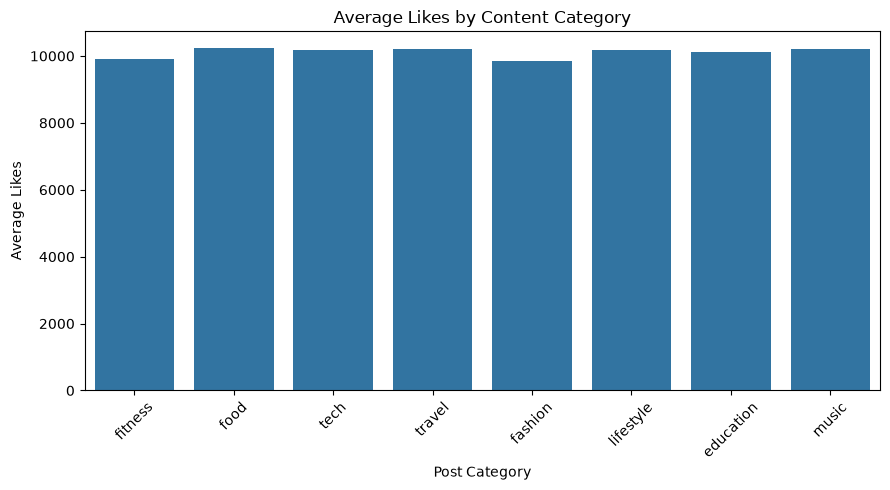

In [53]:
#Bar plot: Average Likes by Category
# Compare average likes across content categories

plt.figure(figsize=(9, 5))

sns.barplot(data=df, x='post_category', y='likes', errorbar=None)

plt.title('Average Likes by Content Category')
plt.xlabel('Post Category')
plt.ylabel('Average Likes')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

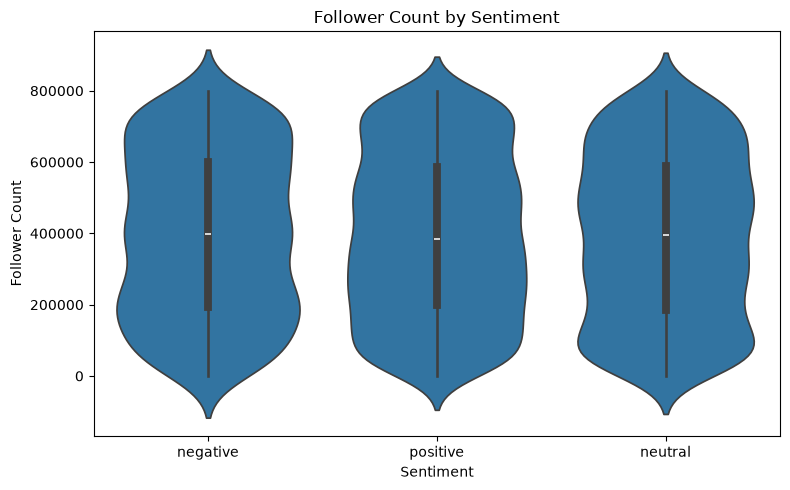

In [54]:
# Violin plot: Followers by Sentiment
# Compare follower counts across sentiment groups

plt.figure(figsize=(8, 5))

sns.violinplot(data=df, x='sentiment', y='follower_count')

plt.title('Follower Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Follower Count')

plt.tight_layout()
plt.show()

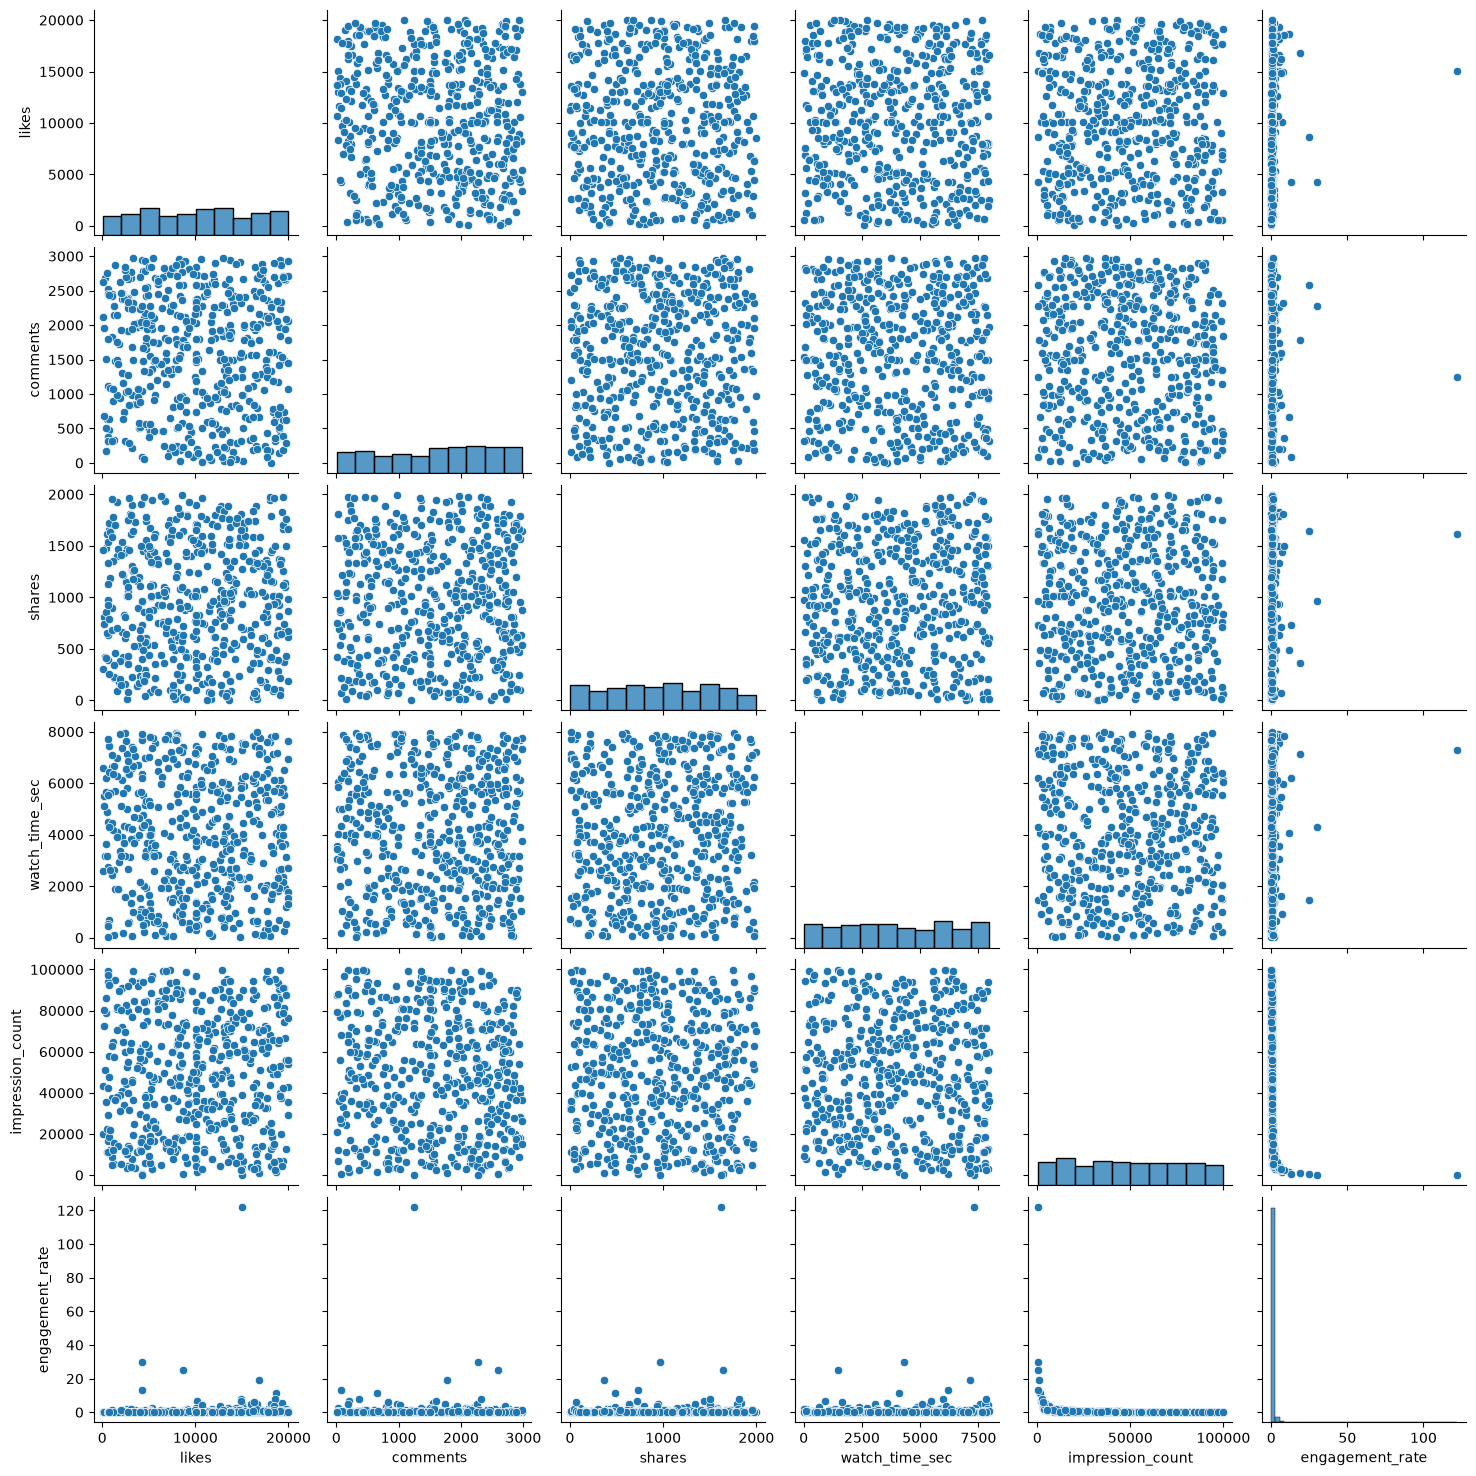

In [55]:
# Pair plot: Numeric Features

#This plot compares several numerical variables against one another. 
# Because dataset has 5,000 rows, I use a sample of 500 to keep it manageable.

# Select numerical columns for comparison

numeric_columns = [
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'impression_count',
    'engagement_rate'
]

# Select 500 rows for the pair plot

sample_data = df[numeric_columns].dropna().sample(
    n=min(500, len(df[numeric_columns].dropna())),
    random_state=42
)

# Draw the pair plot

sns.pairplot(sample_data)

plt.show()

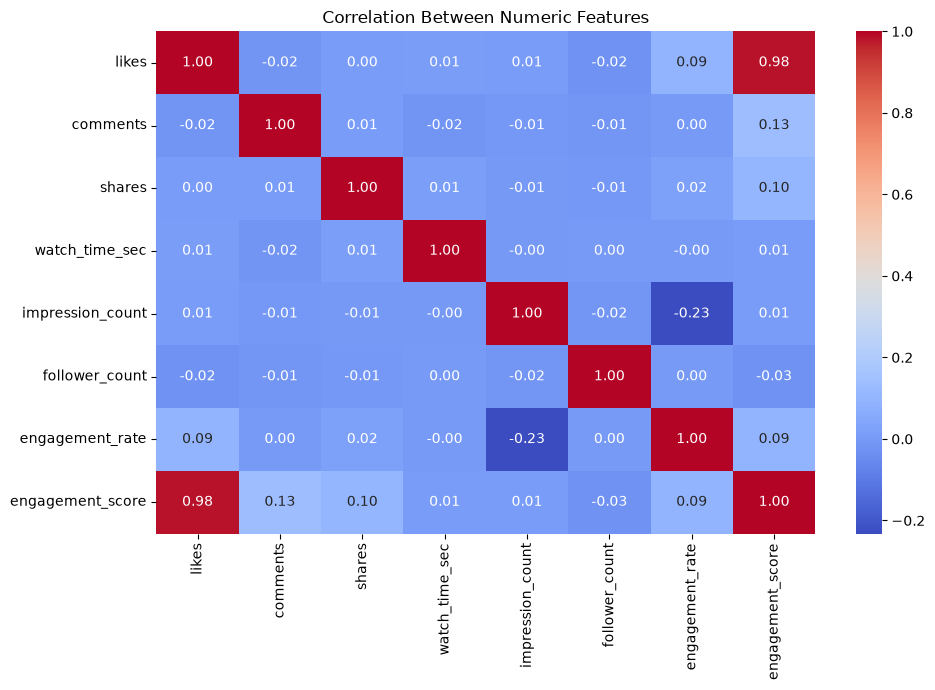

In [56]:
#Heatmap: Correlation Matrix
# Select numerical columns

numeric_columns = [
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'impression_count',
    'follower_count',
    'engagement_rate',
    'engagement_score'
]

# Calculate correlations

correlation = df[numeric_columns].corr()

# Draw the heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Correlation Between Numeric Features')

plt.tight_layout()
plt.show()

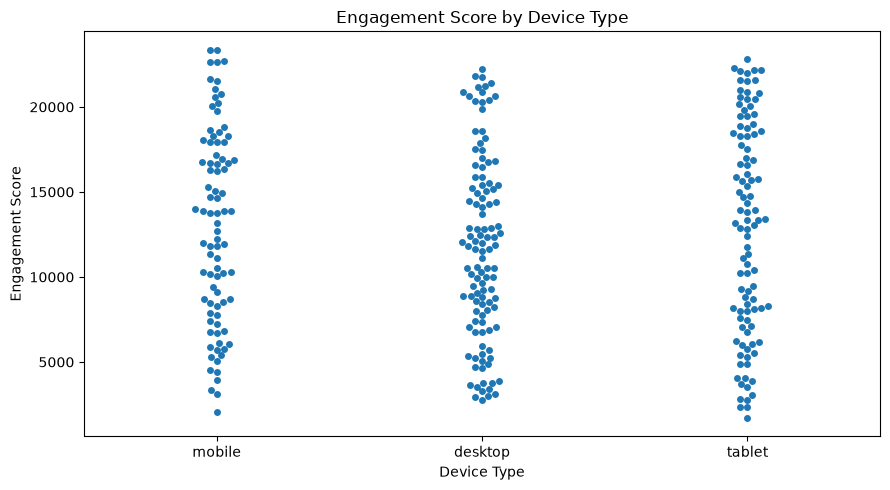

In [57]:
# Swarm plot: Engagement by Device Type
#A swarm plot can become crowded with thousands of points, so I used a sample of 300 posts.

# Select a sample of posts
swarm_data = df.sample(n=min(300, len(df)), random_state=42)

# Draw the swarm plot
plt.figure(figsize=(9, 5))

sns.swarmplot(data=swarm_data, x='device_type', y='engagement_score')

plt.title('Engagement Score by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Engagement Score')

plt.tight_layout()
plt.show()

Part C — Interactive Plotly visualization

In [ ]:
# Interactive bar chart: Average Engagement by Category
# Unlike a standard Matplotlib chart, this chart lets you hover over bars to see values.
import plotly.express as px

interactive_data = df.groupby('post_category', as_index=False).agg(
    average_engagement_rate=('engagement_rate', 'mean'),
    average_likes=('likes', 'mean')
)

fig = px.bar(
    interactive_data,
    x='post_category',
    y='average_engagement_rate',
    title='Average Engagement Rate by Content Category',
    labels={
        'post_category': 'Content Category',
        'average_engagement_rate': 'Average Engagement Rate'
    }
)

fig.show()

Final Insights

In [61]:
#Content Performance — highest engagement by post type
# Find the average engagement for each post type

post_type_analysis = df.groupby('post_type').agg(
    average_likes=('likes', 'mean'),
    average_comments=('comments', 'mean'),
    average_shares=('shares', 'mean'),
    average_engagement=('engagement_score', 'mean'),
    average_engagement_rate=('engagement_rate', 'mean')
).sort_values('average_engagement_rate', ascending=False)

display(post_type_analysis.round(2))

best_post_type = post_type_analysis['average_engagement_rate'].idxmax()

print("Post type with the highest average engagement rate:", best_post_type)

,average_likes,average_comments,average_shares,average_engagement,average_engagement_rate
post_type,,,,,
video,10188.61,1479.16,996.83,12664.61,1.12
text,10100.16,1499.11,1013.99,12613.26,1.06
image,10104.88,1525.24,1019.29,12649.40,0.90
reel,10037.82,1504.19,982.04,12524.05,0.78


Post type with the highest average engagement rate: video


In [62]:
# Content Performance — best-performing content category
# Compare average engagement across content categories

category_analysis = df.groupby('post_category').agg(
    average_likes=('likes', 'mean'),
    average_engagement=('engagement_score', 'mean'),
    average_engagement_rate=('engagement_rate', 'mean')
).sort_values('average_engagement_rate', ascending=False)

display(category_analysis.round(2))

best_category = category_analysis['average_engagement_rate'].idxmax()

print("Best-performing content category:", best_category)

,average_likes,average_engagement,average_engagement_rate
post_category,,,
food,10225.54,12739.22,1.36
tech,10171.58,12686.50,1.16
lifestyle,10180.58,12639.56,1.09
music,10205.76,12788.56,0.89
fitness,9914.61,12457.80,0.87
education,10126.50,12578.29,0.84
fashion,9843.37,12356.44,0.81
travel,10196.32,12650.57,0.70


Best-performing content category: food


In [63]:
# Content Performance — countries with the highest average engagement rate
# Compare engagement rates across countries

country_analysis = df.groupby('country').agg(
    total_posts=('post_id', 'count'),
    average_engagement_rate=('engagement_rate', 'mean'),
    average_likes=('likes', 'mean')
).sort_values('average_engagement_rate', ascending=False)

display(country_analysis.round(2))

print("Top 5 countries by average engagement rate:")
display(country_analysis.head(5).round(2))

,total_posts,average_engagement_rate,average_likes
country,,,
Brazil,504,1.54,9886.70
Australia,493,1.32,10294.14
France,496,1.15,10372.89
UAE,503,1.11,10227.50
Canada,513,0.92,10063.08
UK,493,0.85,9935.66
Japan,472,0.77,10088.87
Germany,490,0.76,10130.48
India,535,0.66,9962.49


Top 5 countries by average engagement rate:


,total_posts,average_engagement_rate,average_likes
country,,,
Brazil,504,1.54,9886.70
Australia,493,1.32,10294.14
France,496,1.15,10372.89
UAE,503,1.11,10227.50
Canada,513,0.92,10063.08


In [64]:
# User Trends — how age affects engagement
# Study the relationship between age and engagement

age_correlation = df['age'].corr(df['engagement_rate'])

print("Correlation between age and engagement rate:", round(age_correlation, 3))

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 17, 24, 34, 44, 54, 64, 100],
    labels=['Under 18', '18-24', '25-34', '35-44',
            '45-54', '55-64', '65+']
)

age_analysis = df.groupby('age_group', observed=True).agg(
    number_of_posts=('post_id', 'count'),
    average_engagement_rate=('engagement_rate', 'mean'),
    average_likes=('likes', 'mean')
)

display(age_analysis.round(2))

print(
    "Age group with the highest average engagement rate:",
    age_analysis['average_engagement_rate'].idxmax()
)

# A positive correlation means engagement tends to increase with age; 
# a negative correlation means it tends to decrease. 
# A value near zero indicates little linear relationship. 
# Compare the age-group averages too, because the relationship may not be perfectly linear.

Correlation between age and engagement rate: 0.008


,number_of_posts,average_engagement_rate,average_likes
age_group,,,
Under 18,448,0.86,10616.76
18-24,636,1.04,10029.11
25-34,977,0.81,10367.41
35-44,1096,0.96,10144.48
45-54,916,1.21,9978.92
55-64,927,0.90,9721.94


Age group with the highest average engagement rate: 45-54


In [65]:
# User Trends — verified vs. unverified accounts
# Compare verified and unverified accounts

verified_analysis = df.groupby('is_verified').agg(
    number_of_posts=('post_id', 'count'),
    average_likes=('likes', 'mean'),
    average_engagement=('engagement_score', 'mean'),
    average_engagement_rate=('engagement_rate', 'mean'),
    average_watch_time=('watch_time_sec', 'mean')
)

display(verified_analysis.round(2))

#This compares the average performance of verified and unverified accounts.
#  Use the actual values in the output to describe the differences; 
# a higher average does not necessarily mean verification itself caused the difference.

,number_of_posts,average_likes,average_engagement,average_engagement_rate,average_watch_time
is_verified,,,,,
False,4517,10137.22,12644.33,0.95,4005.20
True,483,9824.54,12309.29,1.05,4101.49


In [66]:
# Behavioral Insights — best time of day for impressions

# Check whether posting times are available

posted_dates = pd.to_datetime(df['posted_at'], errors='coerce')

has_posting_time = (
    posted_dates.notna().any()
    and (
        (posted_dates.dt.hour != 0)
        | (posted_dates.dt.minute != 0)
        | (posted_dates.dt.second != 0)
    ).any()
)

if has_posting_time:
    df['posting_hour'] = posted_dates.dt.hour

    hourly_analysis = df.groupby('posting_hour').agg(
        average_impressions=('impression_count', 'mean'),
        number_of_posts=('post_id', 'count')
    ).sort_values('average_impressions', ascending=False)

    display(hourly_analysis.round(2))

    print(
        "Hour with the highest average impressions:",
        hourly_analysis.index[0]
    )
else:
    print("Posting time is not available in the dataset.")
    print("The best time of day for impressions cannot be determined.")


Posting time is not available in the dataset.
The best time of day for impressions cannot be determined.


In [67]:
#Behavioral Insights — average impressions by day of the week

#Since the exact posting time is unavailable, I'm investigating whether impressions vary by day of the week. 
# This is a separate analysis, not a replacement for time-of-day analysis.

# Compare impressions across days of the week

df['day_of_week'] = pd.to_datetime(
    df['posted_at'], errors='coerce'
).dt.day_name()

weekday_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]

weekday_analysis = df.groupby('day_of_week').agg(
    average_impressions=('impression_count', 'mean'),
    number_of_posts=('post_id', 'count')
).reindex(weekday_order)

display(weekday_analysis.round(2))

best_day = weekday_analysis['average_impressions'].idxmax()

print("Day with the highest average impressions:", best_day)

,average_impressions,number_of_posts
day_of_week,,
Monday,50013.22,698
Tuesday,51308.59,729
Wednesday,49857.99,700
Thursday,48119.29,698
Friday,49430.54,727
Saturday,50945.23,719
Sunday,50345.67,729


Day with the highest average impressions: Tuesday


In [68]:
# Behavioral Insights — device type and watch time
# Compare average watch time across device types

device_analysis = df.groupby('device_type').agg(
    number_of_posts=('post_id', 'count'),
    average_watch_time=('watch_time_sec', 'mean'),
    average_engagement_rate=('engagement_rate', 'mean'),
    average_impressions=('impression_count', 'mean')
).sort_values('average_watch_time', ascending=False)

display(device_analysis.round(2))

best_device = device_analysis['average_watch_time'].idxmax()

print("Device type with the highest average watch time:", best_device)

,number_of_posts,average_watch_time,average_engagement_rate,average_impressions
device_type,,,,
mobile,1684,4087.83,1.12,49516.95
tablet,1658,3979.74,0.80,49597.97
desktop,1658,3974.79,0.96,50934.07


Device type with the highest average watch time: mobile


In [69]:
# Sentiment Analysis — which sentiment performs best?
# Compare performance by sentiment

sentiment_analysis = df.groupby('sentiment').agg(
    number_of_posts=('post_id', 'count'),
    average_likes=('likes', 'mean'),
    average_comments=('comments', 'mean'),
    average_shares=('shares', 'mean'),
    average_engagement=('engagement_score', 'mean'),
    average_engagement_rate=('engagement_rate', 'mean')
).sort_values('average_engagement_rate', ascending=False)

display(sentiment_analysis.round(2))

best_sentiment = sentiment_analysis['average_engagement_rate'].idxmax()

print("Sentiment with the highest average engagement rate:", best_sentiment)

,number_of_posts,average_likes,average_comments,average_shares,average_engagement,average_engagement_rate
sentiment,,,,,,
negative,960,10208.11,1516.09,1007.31,12731.51,1.04
neutral,1527,9923.21,1528.40,996.57,12448.18,0.99
positive,2513,10180.08,1480.65,1005.09,12665.81,0.92


Sentiment with the highest average engagement rate: negative


In [70]:
# Sentiment Analysis — negative and neutral posts
# Examine the performance of negative and neutral posts

negative_neutral = df[
    df['sentiment'].astype(str).str.strip().str.lower().isin(
        ['negative', 'neutral']
    )
]

negative_neutral_analysis = negative_neutral.groupby('sentiment').agg(
    number_of_posts=('post_id', 'count'),
    average_likes=('likes', 'mean'),
    average_comments=('comments', 'mean'),
    average_shares=('shares', 'mean'),
    average_engagement=('engagement_score', 'mean'),
    average_engagement_rate=('engagement_rate', 'mean'),
    average_watch_time=('watch_time_sec', 'mean')
)

display(negative_neutral_analysis.round(2))

# It Compare the averages for negative and neutral posts. 
# This will show whether either group receives more likes, comments, shares, engagement, 
# or watch time in this dataset.

,number_of_posts,average_likes,average_comments,average_shares,average_engagement,average_engagement_rate,average_watch_time
sentiment,,,,,,,
negative,960,10208.11,1516.09,1007.31,12731.51,1.04,4054.64
neutral,1527,9923.21,1528.40,996.57,12448.18,0.99,4031.82


In [71]:
# Display a final comparison of key findings

# This cell brings the main results together so you can easily refer to them when writing your report.

# Summary of the main findings

print("FINAL INSIGHTS SUMMARY")
print("-" * 40)

print("1. Best-performing post type:", best_post_type)
print("2. Best-performing content category:", best_category)
print("3. Top country by average engagement rate:",
      country_analysis.index[0])
print("4. Age group with highest average engagement rate:",
      age_analysis['average_engagement_rate'].idxmax())
print("5. Device with highest average watch time:", best_device)
print("6. Sentiment with highest average engagement rate:",
      best_sentiment)
print("7. Day with highest average impressions:", best_day)

print("\nAge and engagement correlation:", round(age_correlation, 3))

print("\nVerified account comparison:")
display(verified_analysis.round(2))

print("\nNegative and neutral sentiment comparison:")
display(negative_neutral_analysis.round(2))

FINAL INSIGHTS SUMMARY
----------------------------------------
1. Best-performing post type: video
2. Best-performing content category: food
3. Top country by average engagement rate: Brazil
4. Age group with highest average engagement rate: 45-54
5. Device with highest average watch time: mobile
6. Sentiment with highest average engagement rate: negative
7. Day with highest average impressions: Tuesday

Age and engagement correlation: 0.008

Verified account comparison:


,number_of_posts,average_likes,average_engagement,average_engagement_rate,average_watch_time
is_verified,,,,,
False,4517,10137.22,12644.33,0.95,4005.20
True,483,9824.54,12309.29,1.05,4101.49



Negative and neutral sentiment comparison:


,number_of_posts,average_likes,average_comments,average_shares,average_engagement,average_engagement_rate,average_watch_time
sentiment,,,,,,,
negative,960,10208.11,1516.09,1007.31,12731.51,1.04,4054.64
neutral,1527,9923.21,1528.40,996.57,12448.18,0.99,4031.82


# Social Media Engagement Analytics Using Python

## Project Summary

This project analysed a social media engagement dataset containing 5,000 records. Python libraries including Pandas, NumPy, Matplotlib, Seaborn and Plotly were used to clean the data, explore user behaviour, calculate statistics, visualise patterns and identify content performance trends.

## Data Cleaning and Analysis

Missing values in age, gender, likes, comments, shares and sentiment were handled using median or mode imputation. Duplicate records were checked, data types were corrected, and categorical values were standardised. No negative values were found in likes, comments or shares. New features, including engagement score, hashtag count and log-transformed likes, were created for further analysis.

## Key Findings

*Video posts recorded the highest average engagement rate among post types

*While food was the leading content category by average engagement rate. 

*Brazil had the highest average engagement rate among the countries analysed.

*The relationship between age and engagement rate was almost negligible overall, although the 45–54 age group recorded the highest average rate. 

*Verified accounts had a higher average engagement rate and watch time, whereas unverified accounts recorded higher average likes and total engagement scores.

*Mobile users had the highest average watch time. 

*Tuesday recorded the highest average impressions among the days of the week. 

*Negative posts had the highest average engagement rate, while neutral posts received slightly more comments on average than negative posts.

## Limitations and Conclusion

The dataset did not contain posting-hour information, so the best time of day for impressions could not be identified. Engagement-rate values also showed substantial variation, so results based on this measure should be interpreted cautiously.

Overall, the analysis demonstrates how Python can be used to examine content performance, audience behaviour, device usage and sentiment. The findings describe patterns in this dataset and can help guide further investigation into social media engagement.
